### Step 1- Install Libraries

In [238]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

<b> Step 2- Load Dataset

In [239]:
df = pd.read_csv('data/hr_employee_data.csv')
df.head()

,Employee_ID,Age,Gender,Department,Job_Role,Location,Hire_Date,Exit_Date,Employment_Status,Monthly_Salary,...,Job_Satisfaction,Work_Hours_Per_Week,Overtime_Hours,Training_Hours,Promotions,Absence_Days,Projects_Completed,Remote_Work,Manager_Rating,Attrition
0,EMP10001,25,Male,Sales,Account Manager,Chennai,7/11/2024 18:48,NaN,Active,35600.0,...,1.9,37.0,2,6.0,0,7,8,Yes,4.1,No
1,EMP10002,23,Female,Customer Support,Support Analyst,Mumbai,1/19/2021 22:20,NaN,Active,39900.0,...,3.8,45.4,18,8.0,2,5,4,No,4.9,No
2,EMP10003,30,Male,Operations,Operations Analyst,Bengaluru,1/19/2024 6:13,NaN,Active,62000.0,...,3.1,40.8,1,31.0,1,6,6,No,4.2,No
3,EMP10004,39,Male,HR,HR Analyst,Bengaluru,12/17/2019 8:33,NaN,Active,94700.0,...,2.6,39.2,5,36.0,3,6,3,Yes,3.9,No
4,EMP10005,33,Female,IT,Software Engineer,Delhi NCR,10/20/2024 9:27,NaN,Active,59100.0,...,1.0,43.3,18,33.0,1,9,6,No,3.5,No


In [240]:
df.tail()

,Employee_ID,Age,Gender,Department,Job_Role,Location,Hire_Date,Exit_Date,Employment_Status,Monthly_Salary,...,Job_Satisfaction,Work_Hours_Per_Week,Overtime_Hours,Training_Hours,Promotions,Absence_Days,Projects_Completed,Remote_Work,Manager_Rating,Attrition
1503,EMP10639,35,Male,Sales,Account Manager,Delhi NCR,5/6/2019 21:24,NaN,Active,57300.0,...,4.6,43.0,18,20.0,3,11,7,No,3.7,No
1504,EMP10472,39,Female,Customer Support,Support Manager,Bengaluru,12/12/2022 20:47,NaN,Active,85300.0,...,3.2,36.4,8,6.0,1,2,8,Yes,2.6,No
1505,EMP11150,26,Male,Customer Support,Support Manager,Bengaluru,2/2/2025 22:58,NaN,Active,37900.0,...,4.0,44.1,20,11.0,0,7,5,No,3.3,No
1506,EMP10393,38,Male,Sales,Account Manager,Pune,1/17/2020 19:59,NaN,Active,90100.0,...,3.9,42.1,6,34.0,2,8,8,No,4.4,No
1507,EMP11159,42,Male,Customer Support,Support Analyst,Mumbai,1/22/2020 14:09,NaN,Active,86700.0,...,3.1,44.7,12,32.0,2,4,3,No,3.9,No


In [241]:
df.shape

(1508, 26)

In [242]:
df.columns

Index(['Employee_ID', 'Age', 'Gender', 'Department', 'Job_Role', 'Location',
       'Hire_Date', 'Exit_Date', 'Employment_Status', 'Monthly_Salary',
       'Job_Level', 'Years_At_Company', 'Years_In_Current_Role',
       'Performance_Score', 'Productivity_Score', 'Engagement_Score',
       'Job_Satisfaction', 'Work_Hours_Per_Week', 'Overtime_Hours',
       'Training_Hours', 'Promotions', 'Absence_Days', 'Projects_Completed',
       'Remote_Work', 'Manager_Rating', 'Attrition'],
      dtype='str')

<b> Better

In [243]:
for column in df.columns:
    print(column)

Employee_ID
Age
Gender
Department
Job_Role
Location
Hire_Date
Exit_Date
Employment_Status
Monthly_Salary
Job_Level
Years_At_Company
Years_In_Current_Role
Performance_Score
Productivity_Score
Engagement_Score
Job_Satisfaction
Work_Hours_Per_Week
Overtime_Hours
Training_Hours
Promotions
Absence_Days
Projects_Completed
Remote_Work
Manager_Rating
Attrition


In [244]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1508 entries, 0 to 1507
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Employee_ID            1508 non-null   str    
 1   Age                    1508 non-null   int64  
 2   Gender                 1508 non-null   str    
 3   Department             1508 non-null   str    
 4   Job_Role               1508 non-null   str    
 5   Location               1508 non-null   str    
 6   Hire_Date              1508 non-null   str    
 7   Exit_Date              12 non-null     str    
 8   Employment_Status      1508 non-null   str    
 9   Monthly_Salary         1503 non-null   float64
 10  Job_Level              1508 non-null   str    
 11  Years_At_Company       1508 non-null   float64
 12  Years_In_Current_Role  1508 non-null   float64
 13  Performance_Score      1508 non-null   float64
 14  Productivity_Score     1508 non-null   int64  
 15  Engagement_Scor

In [245]:
df.describe()

,Age,Monthly_Salary,Years_At_Company,Years_In_Current_Role,Performance_Score,Productivity_Score,Engagement_Score,Job_Satisfaction,Work_Hours_Per_Week,Overtime_Hours,Training_Hours,Promotions,Absence_Days,Projects_Completed,Manager_Rating
count,1508.000000,1503.000000,1508.000000,1508.000000,1508.000000,1508.000000,1508.000000,1502.000000,1508.000000,1508.000000,1501.000000,1508.000000,1508.000000,1508.000000,1500.000000
mean,33.915119,66073.186959,4.156631,2.787069,3.506764,96.877984,90.956233,3.410786,41.958355,15.050398,28.097935,1.651194,6.027188,5.304377,3.494067
std,6.693654,21340.377785,2.038814,1.484554,0.737259,5.443902,7.970046,0.862308,2.780087,10.094450,13.727700,1.082689,2.414275,2.256200,0.772007
min,21.000000,25000.000000,0.700000,0.300000,1.400000,69.000000,58.000000,1.000000,33.400000,0.000000,3.000000,0.000000,0.000000,0.000000,1.100000
25%,29.000000,52500.000000,2.400000,1.500000,3.000000,95.000000,86.000000,2.800000,40.100000,8.000000,18.000000,1.000000,4.000000,4.000000,3.000000
50%,34.000000,61900.000000,4.200000,2.700000,3.500000,100.000000,94.000000,3.400000,41.800000,13.000000,28.000000,2.000000,6.000000,5.000000,3.500000
75%,39.000000,84300.000000,5.900000,3.800000,4.000000,100.000000,98.000000,4.000000,43.800000,20.000000,37.000000,2.000000,7.000000,7.000000,4.000000
max,56.000000,142700.000000,7.700000,6.800000,5.000000,100.000000,98.000000,5.000000,50.800000,55.000000,76.000000,4.000000,17.000000,14.000000,5.000000


### Step 3- Data Quality Check

<b> Missing values

In [246]:
df.isnull().sum()

Employee_ID                 0
Age                         0
Gender                      0
Department                  0
Job_Role                    0
Location                    0
Hire_Date                   0
Exit_Date                1496
Employment_Status           0
Monthly_Salary              5
Job_Level                   0
Years_At_Company            0
Years_In_Current_Role       0
Performance_Score           0
Productivity_Score          0
Engagement_Score            0
Job_Satisfaction            6
Work_Hours_Per_Week         0
Overtime_Hours              0
Training_Hours              7
Promotions                  0
Absence_Days                0
Projects_Completed          0
Remote_Work                 0
Manager_Rating              8
Attrition                   0
dtype: int64

<b> Percentage

In [247]:
df.isnull().mean()*100

Employee_ID               0.000000
Age                       0.000000
Gender                    0.000000
Department                0.000000
Job_Role                  0.000000
Location                  0.000000
Hire_Date                 0.000000
Exit_Date                99.204244
Employment_Status         0.000000
Monthly_Salary            0.331565
Job_Level                 0.000000
Years_At_Company          0.000000
Years_In_Current_Role     0.000000
Performance_Score         0.000000
Productivity_Score        0.000000
Engagement_Score          0.000000
Job_Satisfaction          0.397878
Work_Hours_Per_Week       0.000000
Overtime_Hours            0.000000
Training_Hours            0.464191
Promotions                0.000000
Absence_Days              0.000000
Projects_Completed        0.000000
Remote_Work               0.000000
Manager_Rating            0.530504
Attrition                 0.000000
dtype: float64

### Missing Values Treatment

<b> Monthly Salary

In [248]:
df['Monthly_Salary'] = df['Monthly_Salary'].fillna(
    df['Monthly_Salary'].median()
)

<b> Training Hours

In [249]:
df['Training_Hours'] = df['Training_Hours'].fillna(
    df['Training_Hours'].median()
)

<b> Manager Rating

In [250]:
df['Manager_Rating'] = df['Manager_Rating'].fillna(
    df['Manager_Rating'].median()
)

<b> Annual Salary

<b> Job Satisfaction

In [251]:
df['Job_Satisfaction'] = df['Job_Satisfaction'].fillna(
    df['Job_Satisfaction'].median()
)

In [252]:
df.isnull().sum()

Employee_ID                 0
Age                         0
Gender                      0
Department                  0
Job_Role                    0
Location                    0
Hire_Date                   0
Exit_Date                1496
Employment_Status           0
Monthly_Salary              0
Job_Level                   0
Years_At_Company            0
Years_In_Current_Role       0
Performance_Score           0
Productivity_Score          0
Engagement_Score            0
Job_Satisfaction            0
Work_Hours_Per_Week         0
Overtime_Hours              0
Training_Hours              0
Promotions                  0
Absence_Days                0
Projects_Completed          0
Remote_Work                 0
Manager_Rating              0
Attrition                   0
dtype: int64

<b> Standardize Department

In [253]:
df['Department'].value_counts()

Department
IT                  343
Sales               266
Customer Support    246
Operations          246
Finance             162
Marketing           126
HR                  117
it                    2
Name: count, dtype: int64

In [254]:
df['Department'] = df['Department'].str.strip().str.title().replace({'It':'IT'})

In [255]:
df['Department'].value_counts()

Department
IT                  345
Sales               266
Customer Support    246
Operations          246
Finance             162
Marketing           126
Hr                  117
Name: count, dtype: int64

In [256]:
df['Remote_Work'].value_counts()

Remote_Work
No     932
Yes    574
yes      2
Name: count, dtype: int64

In [257]:
df['Remote_Work'] = (
    df['Remote_Work'].str.strip().str.title()
)

In [258]:
df['Remote_Work'].value_counts()

Remote_Work
No     932
Yes    576
Name: count, dtype: int64

<b> Duplicate records

In [259]:
df.duplicated().sum()

np.int64(8)

<b> Unique values

In [260]:
df.nunique()

Employee_ID              1500
Age                        36
Gender                      2
Department                  7
Job_Role                   22
Location                    6
Hire_Date                1500
Exit_Date                  12
Employment_Status           2
Monthly_Salary            636
Job_Level                   4
Years_At_Company           71
Years_In_Current_Role      65
Performance_Score          37
Productivity_Score         32
Engagement_Score           37
Job_Satisfaction           41
Work_Hours_Per_Week       149
Overtime_Hours             54
Training_Hours             68
Promotions                  5
Absence_Days               16
Projects_Completed         15
Remote_Work                 2
Manager_Rating             39
Attrition                   2
dtype: int64

<b> Categorical columns:

In [261]:
df.select_dtypes(include=['object', 'string']).columns

Index(['Employee_ID', 'Gender', 'Department', 'Job_Role', 'Location',
       'Hire_Date', 'Exit_Date', 'Employment_Status', 'Job_Level',
       'Remote_Work', 'Attrition'],
      dtype='str')

<b> Numerical columns:

In [262]:
df.select_dtypes(include=np.number).columns

Index(['Age', 'Monthly_Salary', 'Years_At_Company', 'Years_In_Current_Role',
       'Performance_Score', 'Productivity_Score', 'Engagement_Score',
       'Job_Satisfaction', 'Work_Hours_Per_Week', 'Overtime_Hours',
       'Training_Hours', 'Promotions', 'Absence_Days', 'Projects_Completed',
       'Manager_Rating'],
      dtype='str')

### Step 4- Data Cleaning

In [263]:
df.dtypes

Employee_ID                  str
Age                        int64
Gender                       str
Department                   str
Job_Role                     str
Location                     str
Hire_Date                    str
Exit_Date                    str
Employment_Status            str
Monthly_Salary           float64
Job_Level                    str
Years_At_Company         float64
Years_In_Current_Role    float64
Performance_Score        float64
Productivity_Score         int64
Engagement_Score           int64
Job_Satisfaction         float64
Work_Hours_Per_Week      float64
Overtime_Hours             int64
Training_Hours           float64
Promotions                 int64
Absence_Days               int64
Projects_Completed         int64
Remote_Work                  str
Manager_Rating           float64
Attrition                    str
dtype: object

<b> Date Conversion

In [264]:
df['Hire_Date'] = pd.to_datetime(df['Hire_Date'])
df['Exit_Date'] = pd.to_datetime(df['Exit_Date'])

In [265]:
df.dtypes

Employee_ID                         str
Age                               int64
Gender                              str
Department                          str
Job_Role                            str
Location                            str
Hire_Date                datetime64[us]
Exit_Date                datetime64[us]
Employment_Status                   str
Monthly_Salary                  float64
Job_Level                           str
Years_At_Company                float64
Years_In_Current_Role           float64
Performance_Score               float64
Productivity_Score                int64
Engagement_Score                  int64
Job_Satisfaction                float64
Work_Hours_Per_Week             float64
Overtime_Hours                    int64
Training_Hours                  float64
Promotions                        int64
Absence_Days                      int64
Projects_Completed                int64
Remote_Work                         str
Manager_Rating                  float64


<b> Duplicate remove

In [266]:
df = df.drop_duplicates()

In [267]:
df.duplicated().sum()

np.int64(0)

### Step 5- Feature Engineering

<b> Age Group

In [268]:
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[0,25,35,45,55,100],
    labels=['18-25','25-35','36-45','46-55', '56+']
)
df[['Age_Group']].head()

,Age_Group
0,18-25
1,18-25
2,25-35
3,36-45
4,25-35


<b> Hire Year

In [269]:
df['Hire_Year'] = df['Hire_Date'].dt.year

df[['Hire_Year']].head()

,Hire_Year
0,2024
1,2021
2,2024
3,2019
4,2024


<b> Hire Month

In [270]:
df['Hire_Month'] = df['Hire_Date'].dt.month

df[['Hire_Month']].head()

,Hire_Month
0,7
1,1
2,1
3,12
4,10


<b> Hire Year-Month

In [271]:
df['Hire_Year_Month'] = df['Hire_Date'].dt.to_period('M').astype(str)

df[['Hire_Year_Month']].head()

,Hire_Year_Month
0,2024-07
1,2021-01
2,2024-01
3,2019-12
4,2024-10


<b> Salary Annual

In [272]:
df['Annual_Salary'] = df['Monthly_Salary']*12

df[['Monthly_Salary','Annual_Salary']].head()

,Monthly_Salary,Annual_Salary
0,35600.0,427200.0
1,39900.0,478800.0
2,62000.0,744000.0
3,94700.0,1136400.0
4,59100.0,709200.0


<b> Overtime Category

In [273]:
df['Overtime_Category'] = np.where(
    df['Overtime_Hours'] > 20,
    'High Overtime',
    'Normal Overtime'
)
df[['Overtime_Hours','Overtime_Category']].head()

,Overtime_Hours,Overtime_Category
0,2,Normal Overtime
1,18,Normal Overtime
2,1,Normal Overtime
3,5,Normal Overtime
4,18,Normal Overtime


<b> Engagement Category

In [274]:
df['Engagement_Category'] = np.where(
    df['Engagement_Score'] >=70,
    'High Engagement',
    'Low Engagement'
)

df[['Engagement_Score','Engagement_Category']].head()

,Engagement_Score,Engagement_Category
0,91,High Engagement
1,79,High Engagement
2,96,High Engagement
3,94,High Engagement
4,84,High Engagement


### EDA - Start With Desciptive Statistics

<b> Headcount

In [275]:
total_employee = df['Employee_ID'].nunique()

In [276]:
active_employee = df.loc[df['Employment_Status'] == 'Active','Employee_ID'].nunique()

active_employee

1488

In [277]:
exited_employees = df.loc[df['Employment_Status'] == 'Exited', 'Employee_ID'].nunique()

exited_employees

12

In [278]:
print("Total Employees: ", total_employee)
print("Active Employees: ", active_employee)
print('Exited Employees: ',exited_employees)

Total Employees:  1500
Active Employees:  1488
Exited Employees:  12


### Department Analysis

In [279]:
department_count = (
    df.groupby('Department')['Employee_ID']
      .nunique()
      .sort_values(ascending=False)
)

department_count

Department
IT                  345
Sales               264
Operations          244
Customer Support    243
Finance             161
Marketing           126
Hr                  117
Name: Employee_ID, dtype: int64

<b> Visualization

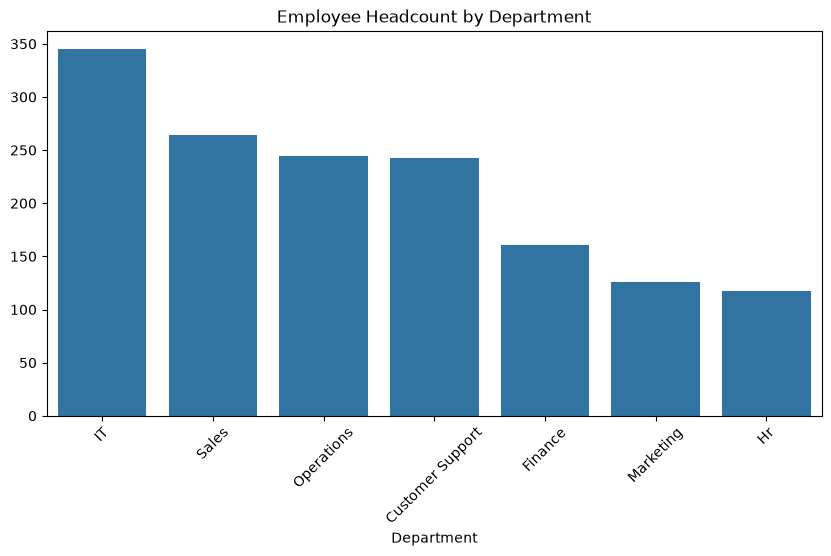

In [280]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=department_count.index,
    y=department_count.values
)

plt.title("Employee Headcount by Department")
plt.xticks(rotation=45)
plt.show()

<b> The company has the most employees in the IT department, while HR has the fewest employees

### Attrition Analysis

In [281]:
attrition_count = df['Attrition'].value_counts()
attrition_count

Attrition
No     1488
Yes      12
Name: count, dtype: int64

<b> Attrition rate:

In [282]:
attrition_rate = (
    df['Attrition'] == 'Yes'
).mean()*100
print(f"Attrition Rate: {attrition_rate: .2f}%")

Attrition Rate:  0.80%


<b> Department-wise

In [283]:
df['Attrition_Flag'] = np.where(
    df['Attrition'] == 'Yes',
    1,
    0
)
department_attrition = (
    df.groupby('Department', as_index=False).agg(
        Total_Employees=('Employee_ID','nunique'),
        Attrition_Count=('Attrition_Flag','sum')
    )
)

department_attrition['Attrition_Rate'] = (
    department_attrition['Attrition_Count'] / department_attrition['Total_Employees'] * 100
)

department_attrition=department_attrition.sort_values(
    'Attrition_Rate', ascending=False
)

department_attrition

,Department,Total_Employees,Attrition_Count,Attrition_Rate
3,IT,345,4,1.159420
2,Hr,117,1,0.854701
0,Customer Support,243,2,0.823045
5,Operations,244,2,0.819672
4,Marketing,126,1,0.793651
6,Sales,264,2,0.757576
1,Finance,161,0,0.000000


<b> Visualization

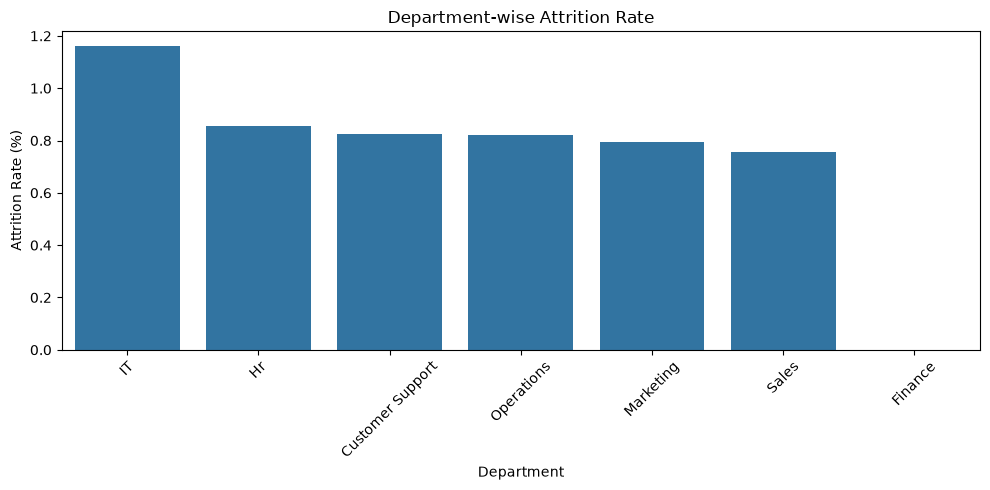

In [284]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data = department_attrition,
    x='Department',
    y='Attrition_Rate'
)

plt.title("Department-wise Attrition Rate")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<b>2. IT has the highest attrition rate, meaning employees are leaving IT at a higher rate compared with the other departments shown.

### Hiring Trend

In [285]:
hiring_trend = (
    df.groupby('Hire_Year')['Employee_ID'].nunique()
)
hiring_trend

Hire_Year
2019    222
2020    207
2021    204
2022    227
2023    186
2024    241
2025    213
Name: Employee_ID, dtype: int64

<b> Line chart:

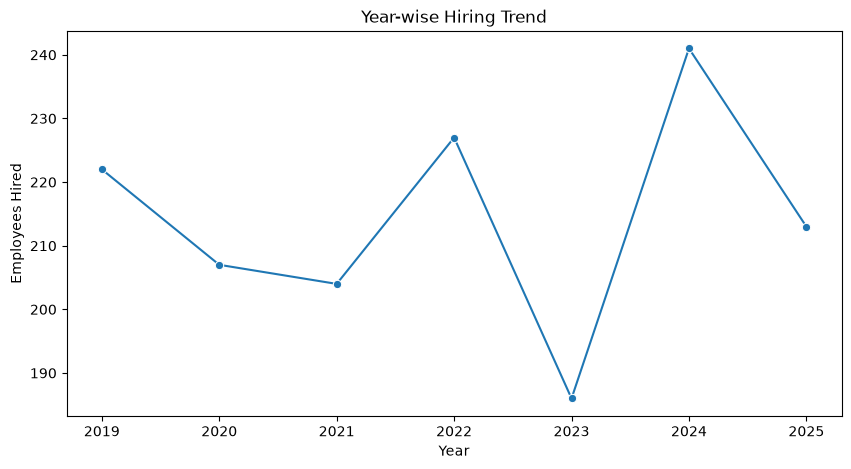

In [286]:
plt.figure(figsize=(10,5))

sns.lineplot(
    x=hiring_trend.index,
    y=hiring_trend.values,
    marker='o'
)

plt.title('Year-wise Hiring Trend')
plt.xlabel("Year")
plt.ylabel("Employees Hired")

plt.show()

##### 3. This chart shows the year-wise hiring trend from 2019 to 2025.
##### Hiring fluctuated during this period, with the lowest hiring 186 employees and the highest in 2024 at around 241 employees.
##### This analysis helps HR understand changes in recruitment activity over time and identify years with higher or lower hiring.

### Performance Analysis

<b> Department performance

In [287]:
performance = (
    df.groupby('Department')['Performance_Score'].mean().sort_values(ascending=False)
)
performance

Department
Marketing           3.597619
Customer Support    3.575309
Hr                  3.547009
IT                  3.515942
Operations          3.494672
Finance             3.436646
Sales               3.415152
Name: Performance_Score, dtype: float64

##### Visualization

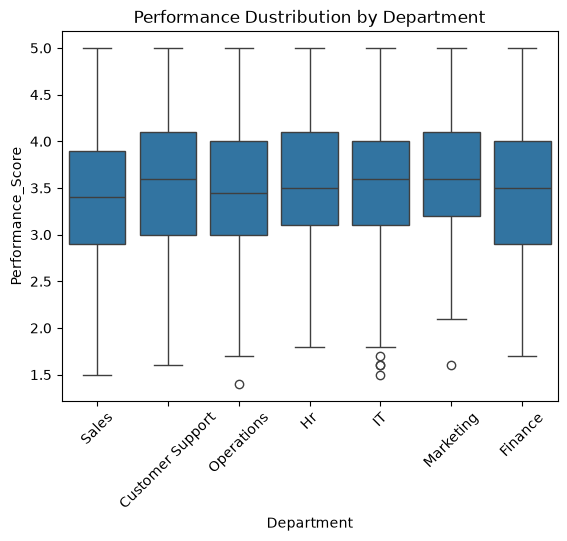

In [288]:
sns.boxplot(
    data=df,
    x='Department',
    y='Performance_Score'
)
plt.xticks(rotation=45)
plt.title("Performance Dustribution by Department")
plt.show()

<b> This is a Performance Distribution by Department graph. It is a box plot, which shows how
employee performance scores are distributed across different departments

#### what does it tell us?
##### The Y-axis = Performance Score, ranging roughly from 1.5 to 5.0
#### For Each department, the box plot shows:

###### Middle line inside the box - median/typical perormance score.
###### Box - where the middle 50% of employee's scores fall.
###### Whiskers - wider range of performance scores.
###### small circles - unsual/low performance scores (outliers).

### what can we observe?

##### Customer Support has slightly higher median performance score, around 3.5.
##### Marketing and IT also have median scores 3.4-3.5
##### Sales and Operations have median scores around 3.4.
##### HR and Finance are also around 3.3-3.4
##### There are some low-performance outliers, especially in IT and Operations.

### Productivity Analysis

<b> Average productivity:

In [289]:
productivity = (
    df.groupby('Department')['Productivity_Score'].mean()
    .sort_values(ascending=False)
)
productivity

Department
Hr                  97.435897
Marketing           97.412698
Finance             97.310559
Customer Support    97.045267
IT                  96.733333
Sales               96.496212
Operations          96.426230
Name: Productivity_Score, dtype: float64

<b> Performance vs Productivity:

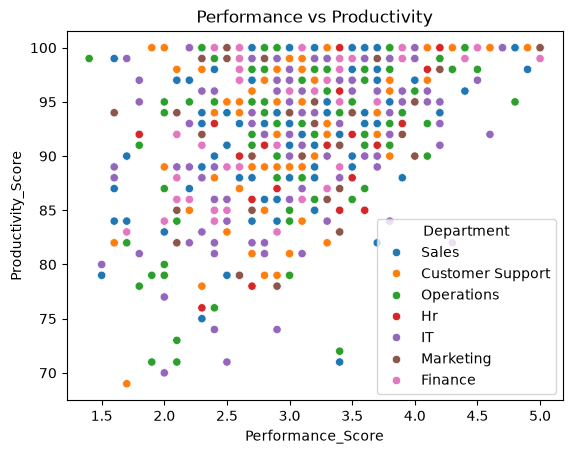

In [290]:
sns.scatterplot(
    data=df,
    x='Performance_Score',
    y='Productivity_Score',
    hue='Department'
)
plt.title("Performance vs Productivity")
plt.show()

<b> This graph is Performance vs Productivity. It is a scatter plot, and it helps us understand whether employees with higher performance scores also have higher productivity scores.

##### Employees with performance around 1.5-2.0 have some productivity scores around 70-80.
##### Employees with performance around 3-4 are mostly concentrated around 85-99.
##### Employees with performance around 4-5 are mostly showing high productivity scores, around 90-100.

##### So, there appears to be a positive relationship between performance and productivity in this dataset.

<b> Correlation:

In [291]:
correlation = df[
    ['Performance_Score','Productivity_Score']
].corr()
correlation

,Performance_Score,Productivity_Score
Performance_Score,1.000000,0.502368
Productivity_Score,0.502368,1.000000


### Engagement Analysis

<b> Department engagement

In [292]:
engagement =(
    df.groupby('Department')['Engagement_Score'].mean()
    .sort_values(ascending=False)
)

engagement

Department
Marketing           92.880952
Hr                  91.846154
Finance             91.273292
Customer Support    90.864198
Sales               90.772727
Operations          90.413934
IT                  90.350725
Name: Engagement_Score, dtype: float64

<b> Engagement vs Attrition

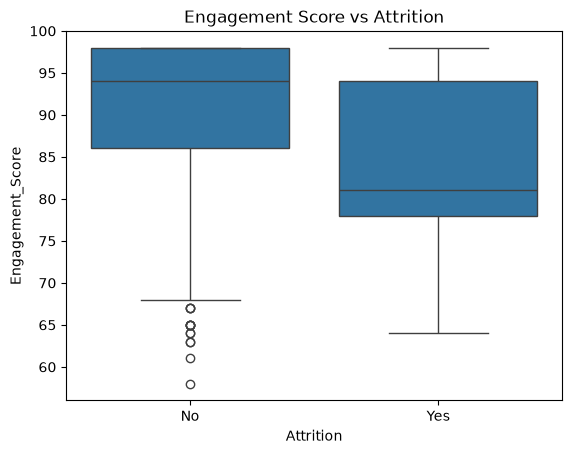

In [293]:
sns.boxplot(
    data=df,
    x='Attrition',
    y='Engagement_Score'
)

plt.title('Engagement Score vs Attrition')
plt.show()

<b> This graph is Engagement Score vs Attrition. It is a box plot comparing employee engagement scores between employees who stayed and employees who left the company.

#### What does it show?

##### No- Employees who did not leave the company.
##### Yes- Employees who left the company
##### y-axis- Employee Engagement Score.

#### From the graph:

##### Employees who stayed have a median engagement score of around 93-94.
##### Employees who left have a median engagement score of around 79-80.
##### so, in this dataset, employees who left generally had lower engagement scores.
##### The "No" group also has some unusually low engagement scores, shown as outliers.

-### Salary Analysis

<b> Department-wise salary

In [294]:
salary_analysis = (
    df.groupby('Department')['Monthly_Salary']
    .agg(['mean','median','min','max'])
    .round(2)
)
salary_analysis

,mean,median,min,max
Department,,,,
Customer Support,66054.73,62000.0,25000.0,141300.0
Finance,66590.68,62500.0,31200.0,124600.0
Hr,65552.14,61900.0,29800.0,123800.0
IT,63366.38,60000.0,25000.0,138600.0
Marketing,69092.86,61150.0,25000.0,133900.0
Operations,65496.31,62450.0,25000.0,139200.0
Sales,68319.70,62900.0,27600.0,142700.0


<b> Salary distribution

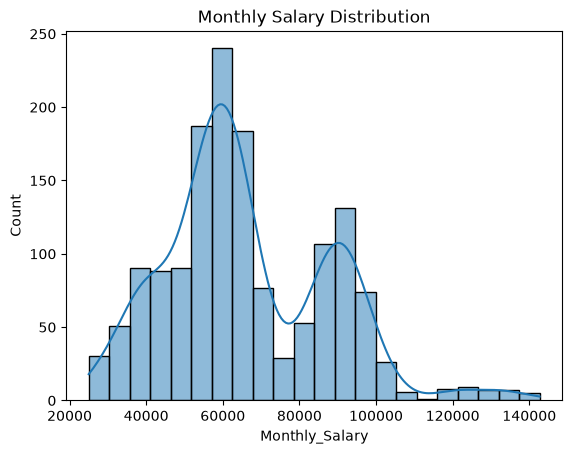

In [295]:
sns.histplot(
    data=df,
    x='Monthly_Salary',
    kde=True
)

plt.title("Monthly Salary Distribution")
plt.show()

### Monthly Salary Distribution

#### This is a histogram showing how employees' monthly salaries are distributed.

##### X-axis: Monthly Salary
##### Y-axis: Number of employees (Count)
##### Most employees' salaries are concentrated around ₹50,000–₹70,000.
##### There is another noticeable group around ₹85,000–₹100,000.
##### Very few employees have salaries above ₹110,000.
##### So, the graph helps HR understand the overall salary structure and salary ranges in the company.

<b> Salary by Job Level

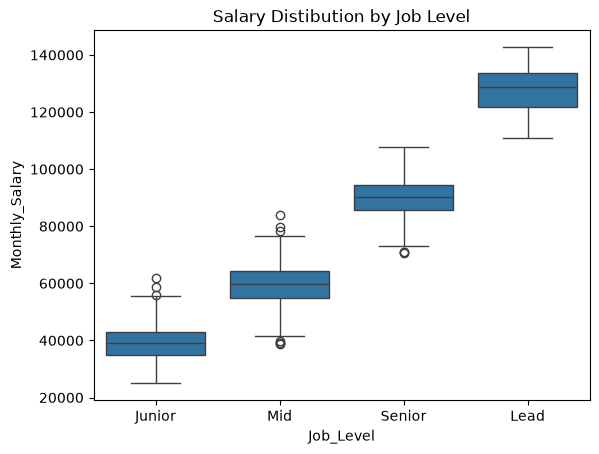

In [296]:
sns.boxplot(
    data=df,
    x='Job_Level',
    y='Monthly_Salary'
)

plt.title("Salary Distibution by Job Level")
plt.show()

### Salary Distribution by Job Level

##### This is a box plot comparing salary across different job levels.

##### Junior: around ₹35k–₹42k
##### Mid: around ₹52k–₹62k
##### Senior: around ₹82k–₹92k
##### Lead: around ₹117k–₹130k
#### What does it tell us?

##### There is a clear pattern: salary increases as the job level increases.

##### For example, Lead employees earn significantly more than Junior employees.

##### The circles outside some boxes are outliers, meaning some employees have salaries unusually high or low compared with others at the same level.

### Overtime Analysis

In [297]:
overtime_attrition = (
    df.groupby('Overtime_Category')['Attrition']
    .apply(lambda x: (x=='Yes').mean()*100)
)

overtime_attrition

Overtime_Category
High Overtime      1.404494
Normal Overtime    0.611888
Name: Attrition, dtype: float64

<b> Visualization

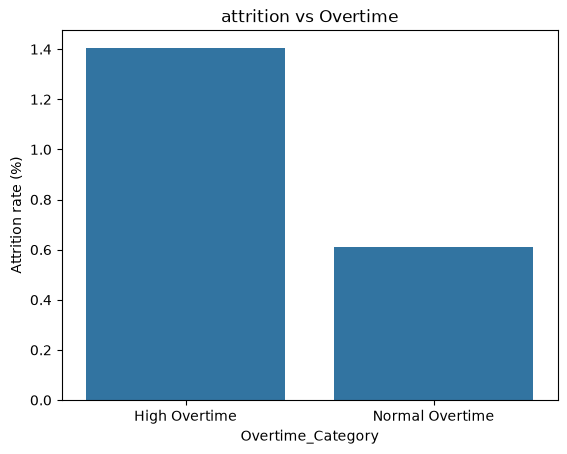

In [298]:
sns.barplot(
    x=overtime_attrition.index,
    y=overtime_attrition.values
)

plt.ylabel("Attrition rate (%)")
plt.title("attrition vs Overtime")
plt.show()

### Attrition vs Overtime

##### This graph compares employee attrition rates based on overtime category.

##### High Overtime: Attrition rate ≈ 1.4%
##### Normal Overtime: Attrition rate ≈ 0.56%

#### What does it mean?

##### Employees in the High Overtime category have a higher attrition rate than employees with Normal Overtime.

##### So, in this dataset, there is an association between higher overtime and higher employee attrition.

### Absenteeism Analysis

In [299]:
absence_department = (
    df.groupby('Department')['Absence_Days']
    .mean()
    .sort_values(ascending=False)
)

absence_department

Department
Operations          6.127049
Sales               6.098485
Customer Support    6.082305
Finance             6.006211
Marketing           5.976190
IT                  5.965217
Hr                  5.760684
Name: Absence_Days, dtype: float64

<b> Visualization

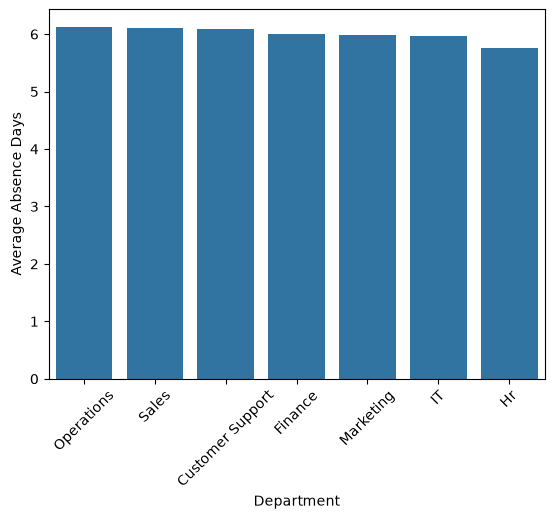

In [300]:
sns.barplot(
    x=absence_department.index,
    y=absence_department.values
)

plt.xticks(rotation=45)
plt.ylabel("Average Absence Days")
plt.show()

<b> This chart shows the average number of absence days across different departments. The average absence is fairly similar across departments, ranging from approximately 5 to 6 days. Operations has the highest average absence, while HR has the lowest. This analysis can help HR identify departments where absenteeism may require further investigation.

### Correlation Analysis

<b> This will be one of the most important EDA sections

In [301]:
numeric_columns = [
    'Age',
    'Monthly_Salary',
    'Years_At_Company',
    'Years_In_Current_Role',
    'Performance_Score',
    'Productivity_Score',
    'Engagement_Score',
    'Job_Satisfaction',
    'Work_Hours_Per_Week',
    'Overtime_Hours',
    'Training_Hours',
    'Promotions',
    'Absence_Days',
    'Projects_Completed',
    'Manager_Rating'
]

<b> Correlation:

In [302]:
corr = df[numeric_columns].corr()

<b> Heatmap:

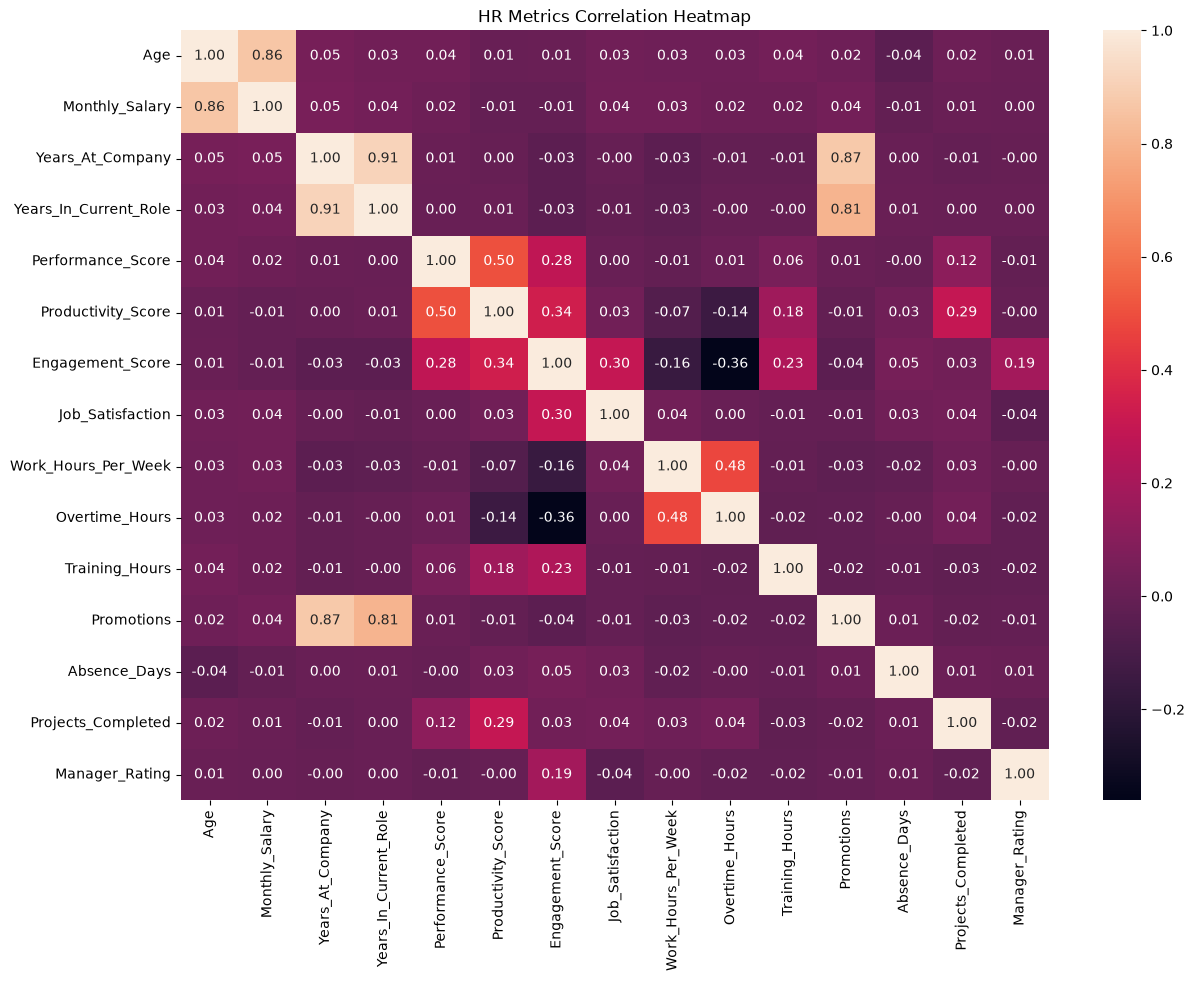

In [303]:
plt.figure(figsize = (14,10))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f'
)

plt.title("HR Metrics Correlation Heatmap")
plt.show()

### HR Metrics Correlation Heatmap

##### This is a Correlation Heatmap. It shows the relationship between different HR metrics.

##### +1 → Strong positive relationship
##### 0 → Almost no relationship
##### -1 → Strong negative relationship
#### Important observations:
##### Age & Monthly Salary = 0.86 → Strong positive relationship. As age increases, salary tends to increase.
##### Years at Company & Years in Current Role = 0.91 → Very strong relationship.
##### Years at Company & Promotions = 0.87 → Strong relationship.
##### Years in Current Role & Promotions = 0.81 → Strong relationship.
##### Performance & Productivity = 0.50 → Moderate positive relationship.
##### Engagement & Overtime Hours = -0.36 → Moderate negative relationship. Higher overtime is associated with lower engagement.
##### Work Hours & Overtime Hours = 0.48 → Moderate positive relationship.

## SQLite Database

<b> Now i'will store the Panda's data into SQLite databse

In [304]:
import sqlite3

conn = sqlite3.connect(
    "database/hr_analytics.db"
)

<b> Load:

In [305]:
df.to_sql(
    'employees',
    conn,
    if_exists='replace',
    index=False
)

1500

<b> Check:

In [306]:
cursor = conn.cursor()

cursor.execute("""
    SELECT COUNT(*) FROM employees
""")

print(cursor.fetchone())

(1500,)


### SQL Analysis

<b> Now we solve the same business questions with SQL

<b> Total Employee

In [307]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("database/hr_analytics.db")

query = """
    SELECT COUNT(DISTINCT Employee_ID) AS total_employees FROM employees;
"""

result = pd.read_sql(query, conn)
result

,total_employees
0,1500


<b> Department Attrition

In [308]:
query = """
    SELECT Department, COUNT(*) AS total_employees,
    SUM(
        CASE
            WHEN Attrition = 'Yes' THEN 1 else 0
        END
    )AS exited_employees
FROM employees
GROUP BY Department
"""
result = pd.read_sql(query, conn)
result

,Department,total_employees,exited_employees
0,Customer Support,243,2
1,Finance,161,0
2,Hr,117,1
3,IT,345,4
4,Marketing,126,1
5,Operations,244,2
6,Sales,264,2


<b> Attrition percentage

In [309]:
query = """
    SELECT Department,
    ROUND(
        100.0 *
        SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END)/COUNT(*),2
    ) as attrition_rate
FROM employees
GROUP BY Department
ORDER BY attrition_rate DESC;
"""

result = pd.read_sql(query, conn)
result

,Department,attrition_rate
0,IT,1.16
1,Hr,0.85
2,Operations,0.82
3,Customer Support,0.82
4,Marketing,0.79
5,Sales,0.76
6,Finance,0.00


In [310]:
query = """
SELECT
    Department,
    COUNT(*) AS Employee_Count,
    ROUND(AVG(Productivity_Score),2) AS Avg_Productivity,
    ROUND(AVG(Engagement_Score),2) AS Avg_Engagement
FROM employees
GROUP BY Department
ORDER BY Employee_Count DESC;
"""

result = pd.read_sql_query(query, conn)

result

,Department,Employee_Count,Avg_Productivity,Avg_Engagement
0,IT,345,96.73,90.35
1,Sales,264,96.50,90.77
2,Operations,244,96.43,90.41
3,Customer Support,243,97.05,90.86
4,Finance,161,97.31,91.27
5,Marketing,126,97.41,92.88
6,Hr,117,97.44,91.85


<b> visulaization

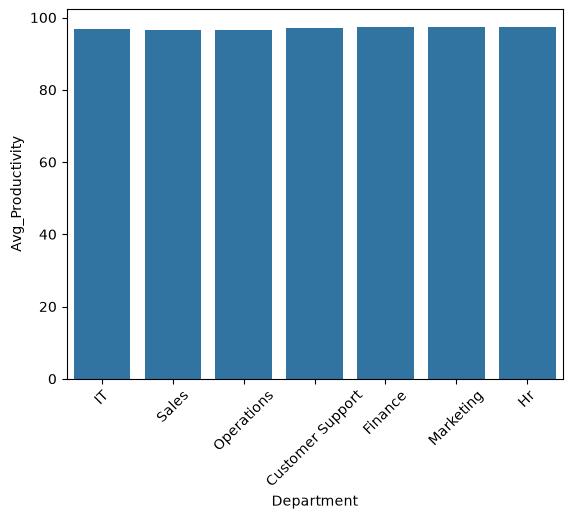

In [311]:
sns.barplot(
    data=result,
    x='Department',
    y='Avg_Productivity'
)

plt.xticks(rotation=45)
plt.show()

<b> This chart compares the average productivity score across different departments. The scores are quite high and relatively similar, ranging from around 96 to 99. HR and Marketing have slightly higher average productivity, while IT and Sales are slightly lower. Overall, the difference between departments is not very significant